*Portfolio Project: Tree Species Classification using LiDAR and Machine Learning*

Import Library

In [1]:
#Import Library
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,mean_squared_error,root_mean_squared_error
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from mlxtend.feature_selection import SequentialFeatureSelector
from sklearn import linear_model

Load Dataset

In [2]:
# Load the dataset
csv=pd.read_csv(r"H:\AfifBelajar\Kaggle LiDAR Inventory\metric_1m.csv",sep=";")
csv

,plot,tree_no,species,d1,d2,dbh,age,height,angle,comment,...,isd,iskew,ikurt,ipground,ipcumzq10,ipcumzq30,ipcumzq50,ipcumzq70,ipcumzq90,geometry
0,1,1,Birch,47.2,46.2,46.70,NaN,26.5,0,NaN,...,12.080981,0.331412,2.100032,12.414553,12.414553,29.768467,50.363837,70.738699,89.570011,"c(547075.839999999, 6450425.24299999)"
1,1,2,Aspen,27.9,29.1,28.50,NaN,NaN,0,NaN,...,11.390441,0.291553,2.030954,2.927652,10.714286,30.931944,50.429185,70.738811,91.201717,"c(547074.299, 6450419.542)"
2,1,3,Fir,12.1,13.0,12.55,NaN,NaN,0,NaN,...,11.927671,0.357784,2.118090,0.000000,10.649034,30.850879,51.174526,72.002784,89.785975,"c(547077.454, 6450419.99399999)"
3,1,4,Aspen,23.3,23.7,23.50,69.0,27.4,0,NaN,...,11.347437,0.489065,2.248289,9.238338,11.916910,31.778426,51.257289,70.025510,89.723032,"c(547078.211, 6450419.01999999)"
4,1,5,Aspen,23.2,31.3,27.25,NaN,NaN,0,NaN,...,11.885771,0.214553,1.945018,0.000000,10.999008,30.681442,51.571287,71.270261,91.283493,"c(547074.668999999, 6450415.57299999)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3597,10,522,Fir,10.0,9.3,9.65,NaN,NaN,0,NaN,...,13.157123,-0.247163,1.634752,0.472731,10.307852,31.211807,50.570737,69.537646,89.980399,"c(546598.562999999, 6449083.92499999)"
3598,10,523,Tilia,19.6,21.0,20.30,NaN,NaN,0,Two tops,...,12.621299,0.319895,1.981169,0.803674,9.427223,28.358209,50.235999,69.957903,89.616022,"c(546594.680999999, 6449079.40199999)"
3599,10,524,Fir,22.8,24.7,23.75,NaN,NaN,0,NaN,...,12.825740,0.202136,1.813108,0.000000,11.965575,31.658338,50.212845,69.905608,89.709421,"c(546576.236999999, 6449102.08999999)"
3600,10,525,Birch,23.3,23.1,23.20,NaN,NaN,0,NaN,...,12.636040,0.088860,1.716068,0.000000,10.267857,31.550656,50.965743,70.052843,89.395044,"c(546600.707, 6449170.21999999)"


In [3]:
#Check Column name and data types
csv.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3602 entries, 0 to 3601
Data columns (total 132 columns):
 #    Column                    Dtype  
---   ------                    -----  
 0    plot                      int64  
 1    tree_no                   int64  
 2    species                   object 
 3    d1                        float64
 4    d2                        float64
 5    dbh                       float64
 6    age                       float64
 7    height                    float64
 8    angle                     int64  
 9    comment                   object 
 10   class                     int64  
 11   n                         float64
 12   zmax                      float64
 13   zmin                      float64
 14   zmean                     float64
 15   zvar                      float64
 16   zsd                       float64
 17   zcv                       float64
 18   zskew                     float64
 19   zkurt                     float64
 20   zq1   

In [9]:
#Create "class" column
csv['class'] = 0

#Assign "Fir" and "Spruce" as class coniferous (1) and the others as deciduous (2)
csv.loc[csv["species"]=='Spruce','class']=1
csv.loc[csv["species"]=='Fir','class']=1

In [15]:
#Create a unique ID column
csv["ID"]=csv["plot"].astype(str)+"_"+csv["tree_no"].astype(str)
csv.head()

,plot,tree_no,species,d1,d2,dbh,age,height,angle,comment,...,iskew,ikurt,ipground,ipcumzq10,ipcumzq30,ipcumzq50,ipcumzq70,ipcumzq90,geometry,ID
0,1,1,Birch,47.2,46.2,46.70,NaN,26.5,0,NaN,...,0.331412,2.100032,12.414553,12.414553,29.768467,50.363837,70.738699,89.570011,"c(547075.839999999, 6450425.24299999)",1_1
1,1,2,Aspen,27.9,29.1,28.50,NaN,NaN,0,NaN,...,0.291553,2.030954,2.927652,10.714286,30.931944,50.429185,70.738811,91.201717,"c(547074.299, 6450419.542)",1_2
2,1,3,Fir,12.1,13.0,12.55,NaN,NaN,0,NaN,...,0.357784,2.118090,0.000000,10.649034,30.850879,51.174526,72.002784,89.785975,"c(547077.454, 6450419.99399999)",1_3
3,1,4,Aspen,23.3,23.7,23.50,69.0,27.4,0,NaN,...,0.489065,2.248289,9.238338,11.916910,31.778426,51.257289,70.025510,89.723032,"c(547078.211, 6450419.01999999)",1_4
4,1,5,Aspen,23.2,31.3,27.25,NaN,NaN,0,NaN,...,0.214553,1.945018,0.000000,10.999008,30.681442,51.571287,71.270261,91.283493,"c(547074.668999999, 6450415.57299999)",1_5


In [17]:
#Remove irrelevant columns
df=csv.drop(columns=['geometry'])
df.head()

,plot,tree_no,species,d1,d2,dbh,age,height,angle,comment,...,isd,iskew,ikurt,ipground,ipcumzq10,ipcumzq30,ipcumzq50,ipcumzq70,ipcumzq90,ID
0,1,1,Birch,47.2,46.2,46.70,NaN,26.5,0,NaN,...,12.080981,0.331412,2.100032,12.414553,12.414553,29.768467,50.363837,70.738699,89.570011,1_1
1,1,2,Aspen,27.9,29.1,28.50,NaN,NaN,0,NaN,...,11.390441,0.291553,2.030954,2.927652,10.714286,30.931944,50.429185,70.738811,91.201717,1_2
2,1,3,Fir,12.1,13.0,12.55,NaN,NaN,0,NaN,...,11.927671,0.357784,2.118090,0.000000,10.649034,30.850879,51.174526,72.002784,89.785975,1_3
3,1,4,Aspen,23.3,23.7,23.50,69.0,27.4,0,NaN,...,11.347437,0.489065,2.248289,9.238338,11.916910,31.778426,51.257289,70.025510,89.723032,1_4
4,1,5,Aspen,23.2,31.3,27.25,NaN,NaN,0,NaN,...,11.885771,0.214553,1.945018,0.000000,10.999008,30.681442,51.571287,71.270261,91.283493,1_5


In [31]:
# Check which columns have NaN values
col_nan = df.columns[df.isna().any()].tolist()
print(f'Columns with at least one NaN value: {col_nan}')

Columns with at least one NaN value: []


In [34]:
df = df.replace(np.nan, 0)
df = df.replace(np.inf, 0)
df = df.replace(-np.inf, 0)

Text(0.5, 1.0, 'Distribution of Class Columns: ')

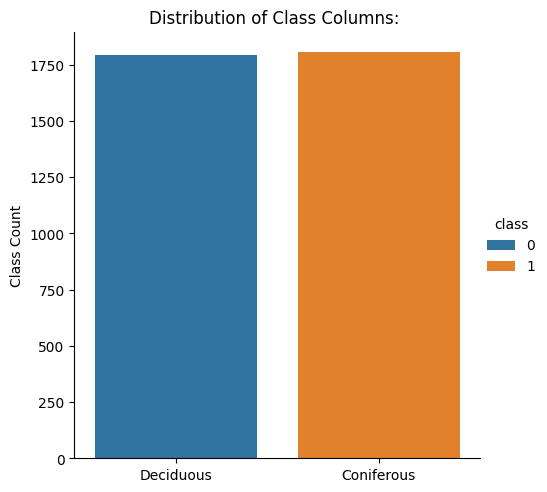

In [7]:
#Data balance checking
g=sns.catplot(data=df, x="class", hue="class", kind="count")
g.set_axis_labels("", "Class Count")
g.set_xticklabels(["Deciduous", "Coniferous"])
plt.title("Distribution of Class Columns: ")

In [ ]:
# Create kernel density estimate (KDE) plot for each column by class

fig, axes = plt.subplots(12,10, figsize=(20, 24))
fig.suptitle('Distribution of metrics by class ', fontsize=12, y=1)
axes = axes.flatten()
col=df.select_dtypes(include=['int64', 'float64']).columns

for i in range(len(col)-1):
    plt.figure(figsize=(12, 10))
    sns.kdeplot(x=col[i],data=df,ax=axes[i])
    axes[i].set_title(f' {col[i]}', fontsize=8)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].set_xticks([])
    axes[i].set_yticks([])

fig.subplots_adjust(top=0.98) 
plt.tight_layout()
plt.show()

In [ ]:
# Create Boxplot for each metrics by class

fig, axes = plt.subplots(12,10, figsize=(20, 24))
fig.suptitle('Boxplot of metrics by class ', fontsize=12, y=1)
axes = axes.flatten()
col=df.select_dtypes(include=['int64', 'float64']).columns

for i in range(len(col)-1):
    plt.figure(figsize=(12, 10))
    sns.boxplot(x='class', y=col[i], data=df, ax=axes[i], hue='class',legend=False)
    axes[i].set_title(f'{col[i]}', fontsize=8)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].set_xticks([])
    axes[i].set_yticks([])

fig.subplots_adjust(top=0.98) 
plt.tight_layout()
plt.show()

Data Split

In [36]:
#Subset the dataframe to seperate the input (X) and target (y) variable

X=df.iloc[0:len(df),11:132]
y=df[["class"]]

print(X)
print(y)

          n     zmax     zmin      zmean        zvar        zsd        zcv  \
0     101.0  26.3885   0.0000  18.590434   86.603224   9.306085  50.058463   
1     139.0  26.7230   0.0000  20.488804   85.843622   9.265183  45.220714   
2     127.0  23.9140   2.6786   9.483075   33.856306   5.818617  61.357918   
3     121.0  25.3192   0.0000  15.248032  106.422111  10.316109  67.655348   
4     129.0  26.5443   2.5748  20.980284   63.290034   7.955503  37.918950   
...     ...      ...      ...        ...         ...        ...        ...   
3597  175.0  17.9648   0.0000  15.315020    3.522809   1.876915  12.255385   
3598  177.0  15.2559   0.0000  13.701331    2.453138   1.566250  11.431369   
3599  236.0  19.9037  10.6435  15.982542    4.907913   2.215381  13.861256   
3600  232.0  20.2550   5.9043  17.355350    9.195048   3.032334  17.472041   
3601  272.0  19.1936   9.1605  13.630962    6.328035   2.515559  18.454740   

         zskew      zkurt        zq1  ...        isd     iskew 

In [37]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

Feature Selection

In [41]:
#Sequential Forward selection

sfs = SequentialFeatureSelector(linear_model.LogisticRegression(max_iter=500),
                                k_features=10,
                                forward=True,
                                floating=False,
                                scoring='accuracy',
                                cv=5)

selected_features = sfs.fit(X_train, y_train)

C:\Users\00028263\.conda\envs\lidar\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\00028263\.conda\envs\lidar\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\00028263\.conda\envs\lidar\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\00028263\.conda\envs\lidar\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected.

In [42]:
sfs_res=pd.DataFrame.from_dict(sfs.get_metric_dict()).T
sfs_res.feature_names[10]

('zq15',
 'zentropy',
 'zpcum8',
 'pz_0.0.15',
 'pz_5.10',
 'rumple',
 'kde_peak4_elev',
 'kde_peak2_value',
 'imean',
 'ipcumzq50')

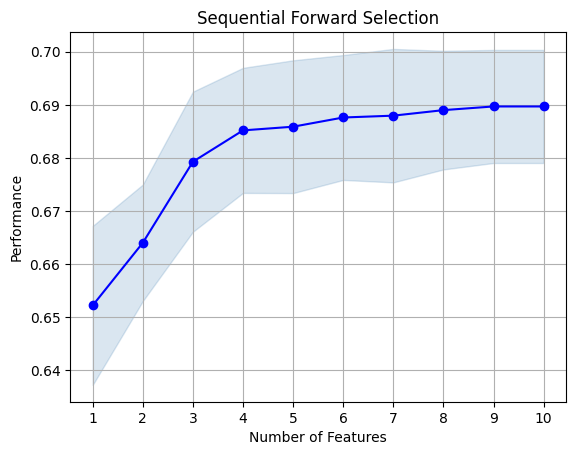

In [43]:
#Plot Selection Result

from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

fig1 = plot_sfs(sfs.get_metric_dict())

plt.title('Sequential Forward Selection')
plt.grid()
plt.show()

In [38]:
# checking for infinity 
print() 
print("checking for infinity") 
  
ds = df.isin([np.inf, -np.inf]) 
print(ds) 
  
# printing the count of infinity values 
print() 
print("printing the count of infinity values") 
  
count = np.isinf(df).values.sum() 
print("It contains " + str(count) + " infinite values") 
  
# counting infinity in a particular column name 
c = np.isinf(df['Weight']).values.sum() 
print("It contains " + str(c) + " infinite values") 
  
# printing column name where infinity is present 
print() 
print("printing column name where infinity is present") 
col_name = df.columns.to_series()[np.isinf(df).any()] 
print(col_name) 
  
# printing row index with infinity 
print() 
print("printing row index with infinity ") 
  
r = df.index[np.isinf(df).any(1)] 
print(r) 


checking for infinity
       plot  tree_no  species     d1     d2    dbh    age  height  angle  \
0     False    False    False  False  False  False  False   False  False   
1     False    False    False  False  False  False  False   False  False   
2     False    False    False  False  False  False  False   False  False   
3     False    False    False  False  False  False  False   False  False   
4     False    False    False  False  False  False  False   False  False   
...     ...      ...      ...    ...    ...    ...    ...     ...    ...   
3597  False    False    False  False  False  False  False   False  False   
3598  False    False    False  False  False  False  False   False  False   
3599  False    False    False  False  False  False  False   False  False   
3600  False    False    False  False  False  False  False   False  False   
3601  False    False    False  False  False  False  False   False  False   

      comment  ...    isd  iskew  ikurt  ipground  ipcumzq10  ip

TypeError: ufunc 'isinf' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

In [40]:
#Subset X data to selected features

X_train_feat=X_train[['zq15',
 'zentropy',
 'zpcum8',
 'pz_0.0.15',
 'pz_5.10',
 'rumple',
 'kde_peak4_elev',
 'kde_peak2_value',
 'imean',
 'ipcumzq50']]
X_test_feat=X_test[['zq15',
 'zentropy',
 'zpcum8',
 'pz_0.0.15',
 'pz_5.10',
 'rumple',
 'kde_peak4_elev',
 'kde_peak2_value',
 'imean',
 'ipcumzq50']]

Model Building (Random Forest)

In [41]:
# Train the random forest model with all metrics and default hyperparameter
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

#K-fold Cross validation
scores = cross_val_score(rf, X_train, y_train, cv=5)


# Predict on the test set
y_pred = rf.predict(X_test)

# Print the model accuracy
accuracy = accuracy_score(y_test, y_pred)


# Calculate Precision, Recall, and F1-Score
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print the results
print("Fitting model with all metrics and default hyperparameters")
print(f"CV scores on train set: {scores.mean()}")
print(f"Model accuracy on test set: {accuracy}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


C:\Users\ACER\miniconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\ACER\miniconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\ACER\miniconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\ACER\miniconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for

Fitting model with all metrics and default hyperparameters
CV scores on train set: 0.7080841998844599
Model accuracy on test set: 0.7434119278779473
Precision: 0.7474
Recall: 0.7434
F1-Score: 0.7438


In [42]:
# Train the random forest model with all metrics and default hyperparameter
rf_feat = RandomForestClassifier()
rf_feat.fit(X_train_feat, y_train)

#K-fold Cross validation
scores = cross_val_score(rf_feat, X_train_feat, y_train, cv=5)

# Predict on the test set
y_pred_def = rf_feat.predict(X_test_feat)

# Print the model accuracy
accuracy_def = accuracy_score(y_test, y_pred_def)

# Calculate Precision, Recall, and F1-Score
precision_def = precision_score(y_test, y_pred_def, average='weighted')
recall_def = recall_score(y_test, y_pred_def, average='weighted')
f1_def = f1_score(y_test, y_pred_def, average='weighted')

# Print the results
print("Fitting model with selected metrics and default hyperparameters")
print(f"CV scores on train set: {scores.mean()}")
print(f"Model accuracy on test set: {accuracy_def}")
print(f"Precision: {precision_def:.4f}")
print(f"Recall: {recall_def:.4f}")
print(f"F1-Score: {f1_def:.4f}")

C:\Users\ACER\miniconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\ACER\miniconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\ACER\miniconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\ACER\miniconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for

Fitting model with selected metrics and default hyperparameters
CV scores on train set: 0.6792773926439437
Model accuracy on test set: 0.7253814147018031
Precision: 0.7282
Recall: 0.7254
F1-Score: 0.7258


Hyperparameter Search

In [132]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100,250,500],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier()
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search =grid_search.fit(X_train_feat, y_train)

print("Best parameters:", grid_search.best_params_)

C:\Users\ACER\miniconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\ACER\miniconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\ACER\miniconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\ACER\miniconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for

Best parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}


In [133]:
print("Best parameters:", grid_search.best_params_)

Best parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}


In [134]:
gs_res=pd.DataFrame.from_dict(grid_search.cv_results_)
gs_res.head(5)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,param_min_samples_split,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,1.010444,0.058929,0.027388,0.013179,None,1,2,100,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.662045,0.666667,0.706597,0.671875,0.704861,0.682409,0.019301,75
1,2.617341,0.299583,0.057892,0.009122,None,1,2,250,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.686308,0.684028,0.696181,0.657986,0.689236,0.682748,0.013038,74
2,4.500300,0.270156,0.098778,0.006659,None,1,2,500,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.696707,0.678819,0.694444,0.668403,0.692708,0.686216,0.010881,58
3,0.867280,0.020776,0.021751,0.007761,None,1,5,100,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.684575,0.675347,0.690972,0.671875,0.699653,0.684485,0.010146,66
4,2.033126,0.017872,0.046874,0.000001,None,1,5,250,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.681109,0.671875,0.685764,0.654514,0.692708,0.677194,0.013207,81


C:\Users\ACER\AppData\Local\Temp\ipykernel_17564\1954040185.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


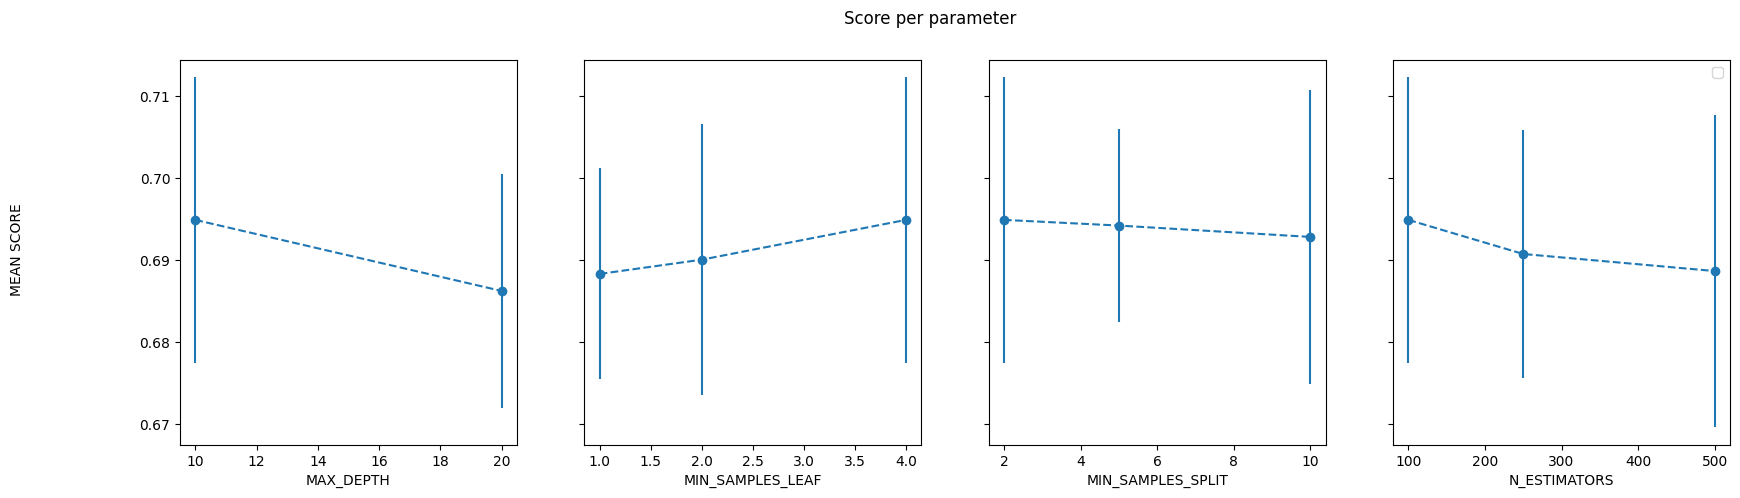

In [135]:
import numpy as np

def plot_search_results(grid):
    """
    Params: 
        grid: A trained GridSearchCV object.
    """
    ## Results from grid search
    results = grid_search.cv_results_
    means_test = results['mean_test_score']
    stds_test = results['std_test_score']

    ## Getting indexes of values per hyper-parameter
    masks=[]
    masks_names= list(grid.best_params_.keys())
    for p_k, p_v in grid.best_params_.items():
        masks.append(list(results['param_'+p_k].data==p_v))

    params=grid.param_grid

    ## Ploting results
    fig, ax = plt.subplots(1,len(params),sharex='none', sharey='all',figsize=(20,5))
    fig.suptitle('Score per parameter')
    fig.text(0.04, 0.5, 'MEAN SCORE', va='center', rotation='vertical')
    pram_preformace_in_best = {}
    for i, p in enumerate(masks_names):
        m = np.stack(masks[:i] + masks[i+1:])
        pram_preformace_in_best
        best_parms_mask = m.all(axis=0)
        best_index = np.where(best_parms_mask)[0]
        x = np.array(params[p])
        y_1 = np.array(means_test[best_index])
        e_1 = np.array(stds_test[best_index])
        ax[i].errorbar(x, y_1, e_1, linestyle='--', marker='o')
        ax[i].set_xlabel(p.upper())

    plt.legend()
    plt.show()

plot_search_results(grid_search)

In [142]:
# Train the random forest model with selected metrics and selected hyperparameters
rf_best = RandomForestClassifier(n_estimators=100,min_samples_leaf=4,min_samples_split=2,max_depth=10)
rf_best.fit(X_train_feat, y_train)

#K-fold Cross validation
scores_best = cross_val_score(rf_best, X_train_feat, y_train, cv=5)

# Predict on the test set
y_pred_best = rf_best.predict(X_test_feat)

# Print the model accuracy
accuracy_best = accuracy_score(y_test, y_pred_best)

# Calculate Precision, Recall, and F1-Score
precision_best = precision_score(y_test, y_pred_best, average='weighted')
recall_best = recall_score(y_test, y_pred_best, average='weighted')
f1_best = f1_score(y_test, y_pred_best, average='weighted')

# Print the results
print("Fitting model with selected metrics and selected hyperparameters")
print(f"CV scores on train set: {scores.mean()}")
print(f"Model accuracy on test set: {accuracy_best}")
print(f"Precision: {precision_best:.4f}")
print(f"Recall: {recall_best:.4f}")
print(f"F1-Score: {f1_best:.4f}")

C:\Users\ACER\miniconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\ACER\miniconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\ACER\miniconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\ACER\miniconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for

Fitting model with selected metrics and selected hyperparameters
CV scores on train set: 0.6792773926439437
Model accuracy on test set: 0.7128987517337032
Precision: 0.7179
Recall: 0.7129
F1-Score: 0.7133


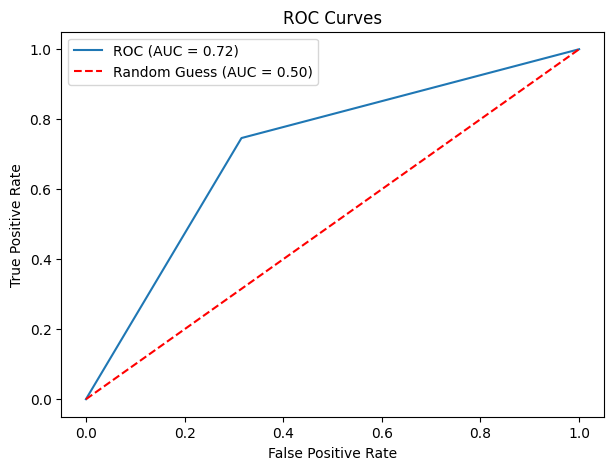

In [143]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(7, 5))

fpr, tpr, _ = roc_curve(y_test, y_pred_best)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'r--', label='Random Guess (AUC = 0.50)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()

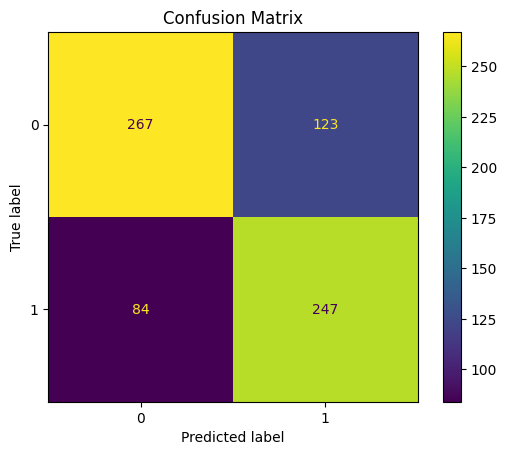

In [144]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion Matrix')

plt.show()

In [98]:
#Merge array of predicted and reference
pred_merge = np.column_stack((y_test.to_numpy().flatten(),y_pred_best))
pred_merge

array([[1, 1],
       [1, 1],
       [0, 0],
       ...,
       [1, 0],
       [0, 1],
       [1, 0]], shape=(721, 2))

In [129]:
#Map the result into the rest of dataset
df_pred = pd.DataFrame(pred_merge,columns=("ref","pred"))
df_final= pd.concat([X_test[["ID"]].reset_index(drop=True), df_pred.reset_index(drop=True) ], axis=1)
df_final=df_final.merge(csv[["ID","species","geometry"]],on="ID",how="left")
df_final.head()

,ID,ref,pred,species,geometry
0,7_89,1,1,Spruce,"c(545762.025999999, 6449348.716)"
1,9_10,1,1,Spruce,"c(546244.177999999, 6449182.96399999)"
2,7_226,0,0,Birch,"c(545793.652, 6449335.29)"
3,5_128,1,1,Spruce,"c(545711.01, 6449887.47099999)"
4,4_11,0,0,Birch,"c(546017.696331999, 6449504.95863)"


In [131]:
#Export the result

df_final.to_csv(r"H:\AfifBelajar\Kaggle LiDAR Inventory\result.csv",sep=";")